# Multiple Instance Detection

Scenes `m1..m5`, products `{0, 1, 11, 19, 24, 25, 26}`.

Detect multiple instances of the same porduct in one scene.

Task B solution is divided in two; 
1. Single pair walkthrough for debug and testing
2. Compact run function across all scenes and model images

# Setup

In [95]:
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

# Paths and the Task B dataset
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "tasks" else Path.cwd()
MODELS_DIR = PROJECT_ROOT / "models"
SCENES_DIR = PROJECT_ROOT / "scenes"
STEP_B_SCENES   = [f"m{i}.png" for i in range(1, 6)]
STEP_B_PRODUCTS = ["0", "1", "11", "19", "24", "25", "26"]

LOWE_RATIO = 0.7              
MIN_GOOD_MATCHES = 10         # need this many post-Lowe matches to attempt GHT

# GHT-specific parameters
VOTE_BIN_SIZE = 10           # accumulator bin in pixels (smaller = precise, more noise)
MIN_PEAK_VOTES = 8           # minimum votes for a bin to count as a candidate peak
PEAK_SUPPRESSION_RADIUS = 150 # min distance (px) between separate peaks

# Colour check — same approach as Task A (BGR mean Euclidean)
COLOR_TOL = 50               # max BGR Euclidean distance between model and instance bbox


# Visualizating wrapper — BGR (OpenCV) -> RGB (matplotlib)
def show_bgr(bgr, title="", figsize=(10, 6)):
    plt.figure(figsize=figsize)
    plt.imshow(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB))
    plt.title(title); plt.axis("off"); plt.show()

# Single pair of instance detection debug tool

Takes only one model and scene image. 
Cells print out information valuable for debuging.

## 1. Load model and scene

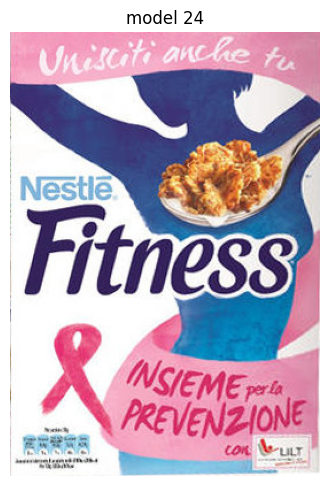

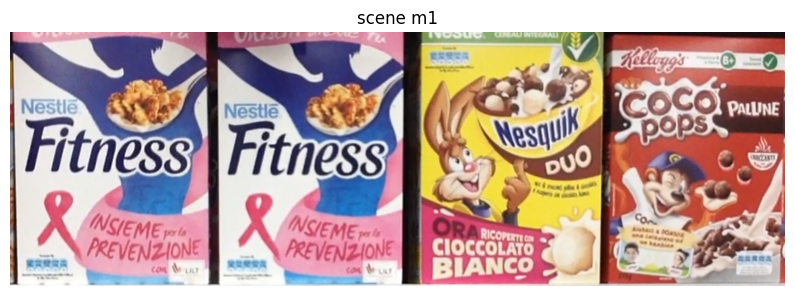

In [71]:
def load_pair(model_id, scene_id):
    model_bgr = cv2.imread(str(MODELS_DIR / f"{model_id}.jpg"), cv2.IMREAD_COLOR)
    scene_bgr = cv2.imread(str(SCENES_DIR / f"{scene_id}.png"), cv2.IMREAD_COLOR)
    model_gray = cv2.cvtColor(model_bgr, cv2.COLOR_BGR2GRAY)
    scene_gray = cv2.cvtColor(scene_bgr, cv2.COLOR_BGR2GRAY)
    return model_bgr, scene_bgr, model_gray, scene_gray


model_id = "24"
scene_id = "m1"
model_bgr, scene_bgr, model_gray, scene_gray = load_pair(model_id, scene_id)

show_bgr(model_bgr, title=f"model {model_id}", figsize=(4, 6))
show_bgr(scene_bgr, title=f"scene {scene_id}")

## 2. SIFT — keypoints, descriptors, and joining vectors

In this cell, SIFT is used to extract keypoints and descriptors from the model and scene images. The `compute_joining_vectors` function calculates the vectors from each model keypoint to the barycenter of the model, which will be used later in the Generalized Hough Transform (GHT) for voting. Finally, it visualizes the detected keypoints on both images using `cv2.drawKeypoints` with the `DRAW_RICH_KEYPOINTS` flag, which draws circles scaled to the keypoint size and lines indicating orientation.


Keypoints (model): 1084
Keypoints (scene): 6355
Number of model descriptors: 1084
Joining vectors shape: (1084, 2)


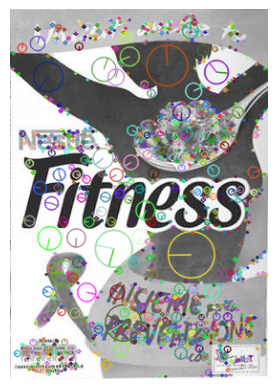

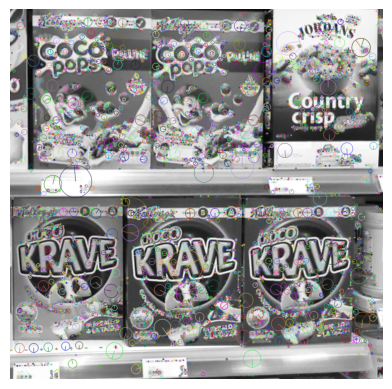

In [ ]:
sift = cv2.SIFT_create()

def get_features(img_gray):
    return sift.detectAndCompute(img_gray, None)

def compute_joining_vectors(kp, model_shape):
    h, w = model_shape
    barycenter = np.array([w / 2, h / 2])
    return np.array([barycenter - k.pt for k in kp])


kp_reference, des_reference = get_features(model_gray)
kp_target, des_target = get_features(scene_gray)
joining_vectors = compute_joining_vectors(kp_reference, model_gray.shape)

print("Keypoints (model):", len(kp_reference))
print("Keypoints (scene):", len(kp_target))
print("Number of model descriptors:", len(des_reference))
print("Joining vectors shape:", joining_vectors.shape)

# DRAW_RICH_KEYPOINTS draws a circle scaled to keypoint size + a line for orientation
img_m = cv2.drawKeypoints(model_gray, kp_reference, None,
                          flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
img_s = cv2.drawKeypoints(scene_gray, kp_target, None,
                          flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
plt.imshow(img_m); plt.axis('off'); plt.show()
plt.imshow(img_s); plt.axis('off'); plt.show()

## 3. Feature matching — FLANN + Lowe's ratio test

FLANN finds the 2 nearest scene descriptors for each model descriptor. Lowe's ratio test keeps only matches where the closest neighbour is clearly closer than the second one.

In [75]:
def match_descriptors(des_m, des_s, ratio=LOWE_RATIO):
    matcher = cv2.FlannBasedMatcher(dict(algorithm=1, trees=5), dict(checks=50))
    matches = matcher.knnMatch(des_m, des_s, k=2)
    return [m for m, n in matches if m.distance < ratio * n.distance]


good_matches = match_descriptors(des_reference, des_target)
print(f"Total matches (1 per model descriptor): {len(des_reference)}")
print(f"Good matches after Lowe (ratio={LOWE_RATIO}):", len(good_matches))

Total matches (1 per model descriptor): 1084
Good matches after Lowe (ratio=0.7): 222


## 4. GHT voting + peak detection

Each match votes for where the model's barycenter would be in the scene, scaled by the keypoint size ratio (the same model feature can appear larger or smaller in the scene). Votes accumulate in a 2D bin grid; local maxima above `MIN_PEAK_VOTES` are kept as candidate instance centers.

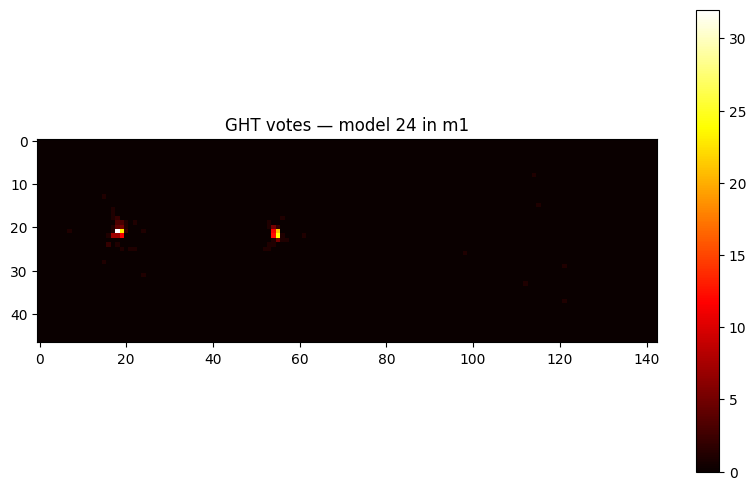

Found 2 peak(s) above 8 votes
  Peak 1: scene pos (185, 215)
  Peak 2: scene pos (555, 225)


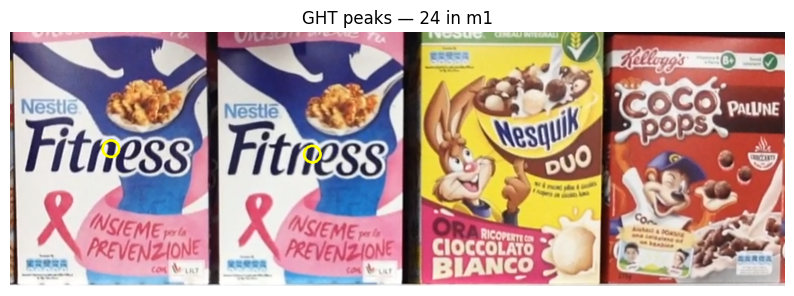

In [76]:
def ght_vote_and_peaks(good, kp_m, kp_s, jvecs, scene_shape):
    scene_h, scene_w = scene_shape
    acc_h = scene_h // VOTE_BIN_SIZE + 1
    acc_w = scene_w // VOTE_BIN_SIZE + 1
    accumulator = np.zeros((acc_h, acc_w), dtype=np.float32)

    # Precompute every vote (also returned for downstream bbox sizing)
    votes = []
    for m in good:
        model_kp = kp_m[m.queryIdx]
        scene_kp = kp_s[m.trainIdx]
        scale = scene_kp.size / model_kp.size
        v_scaled = jvecs[m.queryIdx] * scale
        vote_x = scene_kp.pt[0] + v_scaled[0]
        vote_y = scene_kp.pt[1] + v_scaled[1]
        votes.append((vote_x, vote_y, scale))

        bin_x = int(vote_x // VOTE_BIN_SIZE)
        bin_y = int(vote_y // VOTE_BIN_SIZE)
        if 0 <= bin_x < acc_w and 0 <= bin_y < acc_h:
            accumulator[bin_y, bin_x] += 1

    # Peak detection: a peak is a local max (cv2.dilate replaces each pixel with
    # the max in its neighbourhood, so original == dilated iff local max).
    neighborhood = max(1, PEAK_SUPPRESSION_RADIUS // VOTE_BIN_SIZE)
    kernel = np.ones((neighborhood, neighborhood), np.uint8)
    is_local_max = (accumulator == cv2.dilate(accumulator, kernel)) & (accumulator >= MIN_PEAK_VOTES)

    peak_ys, peak_xs = np.where(is_local_max)
    peaks = [(int(x * VOTE_BIN_SIZE + VOTE_BIN_SIZE / 2),
              int(y * VOTE_BIN_SIZE + VOTE_BIN_SIZE / 2))
             for x, y in zip(peak_xs, peak_ys)]

    return accumulator, peaks, votes


accumulator, peaks, votes = ght_vote_and_peaks(
    good_matches, kp_reference, kp_target, joining_vectors, scene_gray.shape)

plt.figure(figsize=(10, 6))
plt.imshow(accumulator, cmap='hot')
plt.title(f"GHT votes — model {model_id} in {scene_id}")
plt.colorbar(); plt.show()

print(f"Found {len(peaks)} peak(s) above {MIN_PEAK_VOTES} votes")
for i, p in enumerate(peaks, start=1):
    print(f"  Peak {i}: scene pos {p}")

# Mark peaks on the scene image
scene_with_peaks = scene_bgr.copy()
for p in peaks:
    cv2.circle(scene_with_peaks, p, 15, (0, 255, 255), 3)
show_bgr(scene_with_peaks, title=f"GHT peaks — {model_id} in {scene_id}")

## 5. Per-peak bounding boxes

The peaks_to_instances function takes the GHT peaks and their associated votes to estimate
the bounding boxes of candidate instances. It uses the median scale of votes near each peak
to size the bounding box based on the model's dimensions.

In [ ]:
def peaks_to_instances(peaks, votes, model_shape):
    mh, mw = model_shape
    r2 = PEAK_SUPPRESSION_RADIUS ** 2 # radius for associating votes to peaks when estimating bbox size
    instances = []
    for peak_x, peak_y in peaks:
        scales = [s for vx, vy, s in votes if (vx - peak_x)**2 + (vy - peak_y)**2 <= r2]
        if not scales:
            continue
        med_scale = float(np.median(scales))
        instances.append({
            "center": (peak_x, peak_y),
            "width":  int(mw * med_scale),
            "height": int(mh * med_scale),
            "scale":  med_scale,
        })
    return instances


instances = peaks_to_instances(peaks, votes, model_gray.shape)

print(f"Built {len(instances)} candidate bbox(es) for model {model_id} in {scene_id}")
for i, inst in enumerate(instances, start=1):
    print(f"  Instance {i}: center={inst['center']}, "
          f"w={inst['width']}, h={inst['height']}, scale={inst['scale']:.2f}")

Built 2 candidate bbox(es) for model 24 in m1
  Instance 1: center=(185, 215), w=356, h=510, scale=1.32
  Instance 2: center=(555, 225), w=343, h=492, scale=1.27


## 6. Colour verification — mean BGR + Euclidean distance

In this cell the colour distance between the model and each candidate instance is computed by
comparing the mean BGR colour of the model image to the mean BGR colour of the scene image within the candidate instance's bounding box. The colour distance is calculated as the Euclidean distance between the two mean BGR values. If the colour distance is below a specified tolerance (COLOR_T)


In [ ]:

def quad_mask(scene_shape, warped):
    m = np.zeros(scene_shape[:2], np.uint8)
    cv2.fillPoly(m, [np.int32(warped)], 255)
    return m

def mean_bgr(img, mask=None):
    return np.array(cv2.mean(img, mask=mask)[:3])

def color_distance(model_bgr, scene_bgr, warped):
    m_model = mean_bgr(model_bgr)
    m_scene = mean_bgr(scene_bgr, mask=quad_mask(scene_bgr.shape, warped))
    return float(np.linalg.norm(m_model - m_scene))

def instance_to_quad(inst):
    cx, cy = inst["center"]
    w, h = inst["width"], inst["height"]
    x0, y0 = cx - w // 2, cy - h // 2
    return np.float32([[x0, y0], [x0, y0+h], [x0+w, y0+h], [x0+w, y0]]).reshape(-1, 1, 2)


if not instances:
    print(f"No instances to colour-check for model {model_id} in scene {scene_id}.")
    accepted_instances = []
else:
    accepted_instances = []
    for i, inst in enumerate(instances, start=1):
        warped = instance_to_quad(inst)
        dist = color_distance(model_bgr, scene_bgr, warped)
        verdict = "ACCEPT" if dist <= COLOR_TOL else "REJECT"
        print(f"Instance {i}: colour distance {dist:.2f}  [{verdict} at COLOR_TOL={COLOR_TOL}]")
        if dist <= COLOR_TOL:
            accepted_instances.append(inst)

Instance 1: colour distance 7.97  [ACCEPT at COLOR_TOL=50]
Instance 2: colour distance 18.32  [ACCEPT at COLOR_TOL=50]


## 7. Final visualization

Draw a green bounding box for every instance that survived the colour check, plus a centre marker. Nothing is drawn for rejected instances.

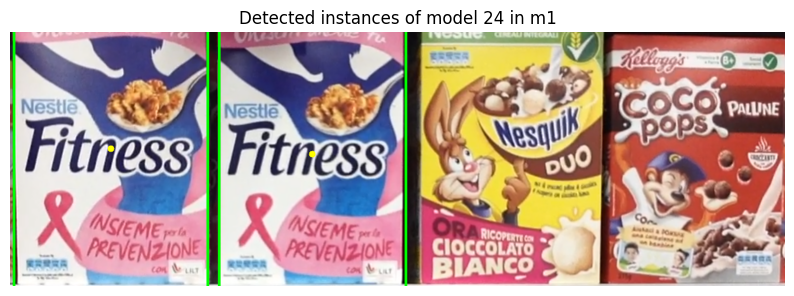

2 instance(s) drawn after colour check.


In [ ]:
if not accepted_instances: # If no instances passed the colour check, viusalization is skipped
    print(f"No instances to visualize for model {model_id} in scene {scene_id}.")
else:
    scene_with_boxes = scene_bgr.copy() 
    for inst in accepted_instances: # 
        cx, cy = inst["center"]
        x0, y0 = cx - inst["width"] // 2, cy - inst["height"] // 2
        cv2.rectangle(scene_with_boxes, (x0, y0),
                      (x0 + inst["width"], y0 + inst["height"]), (0, 255, 0), 3)
        cv2.circle(scene_with_boxes, (cx, cy), 6, (0, 255, 255), -1)

    show_bgr(scene_with_boxes, title=f"Detected instances of model {model_id} in {scene_id}")
    print(f"{len(accepted_instances)} instance(s) drawn after colour check.")

# Multi-pair sweep — iterative masking

For each scene we iteratively pick the product with the strongest accepted GHT detections, black out its bounding boxes in the scene, then repeat with the remaining products. Each product can place all its instances in one pass (GHT handles same-product multiplicity), and masking prevents another product from claiming those regions in later iterations.


Processing scene: m1


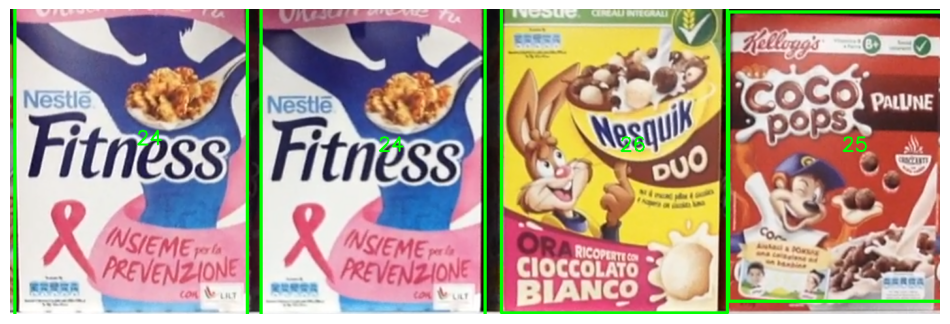

Product 0: 0 instance(s) found
Product 1: 0 instance(s) found
Product 11: 0 instance(s) found
Product 19: 0 instance(s) found
Product 24: 2 instance(s) found
  Instance 1 {position: (7, -40), width: 356px, height: 510px}
  Instance 2 {position: (384, -21), width: 343px, height: 492px}
Product 25: 1 instance(s) found
  Instance 1 {position: (1100, 4), width: 330px, height: 443px}
Product 26: 1 instance(s) found
  Instance 1 {position: (752, -15), width: 346px, height: 480px}

Processing scene: m2


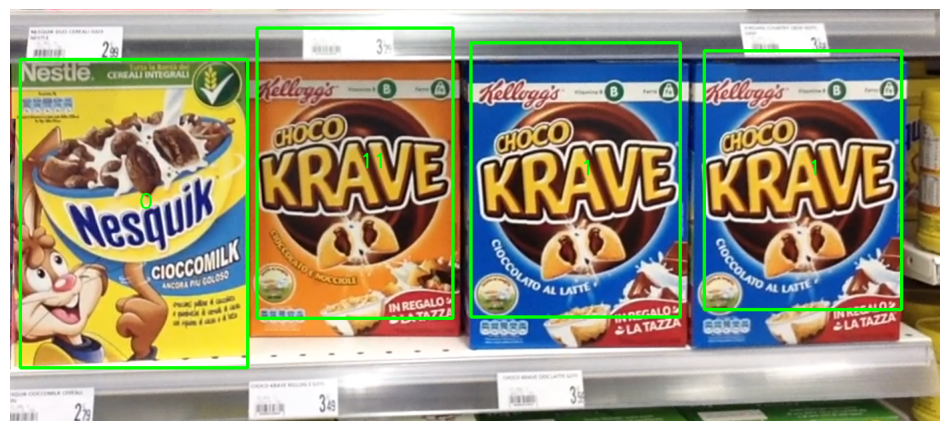

Product 0: 1 instance(s) found
  Instance 1 {position: (15, 75), width: 340px, height: 461px}
Product 1: 2 instance(s) found
  Instance 1 {position: (689, 50), width: 313px, height: 410px}
  Instance 2 {position: (1038, 62), width: 295px, height: 387px}
Product 11: 1 instance(s) found
  Instance 1 {position: (369, 28), width: 293px, height: 434px}
Product 19: 0 instance(s) found
Product 24: 0 instance(s) found
Product 25: 0 instance(s) found
Product 26: 0 instance(s) found

Processing scene: m3


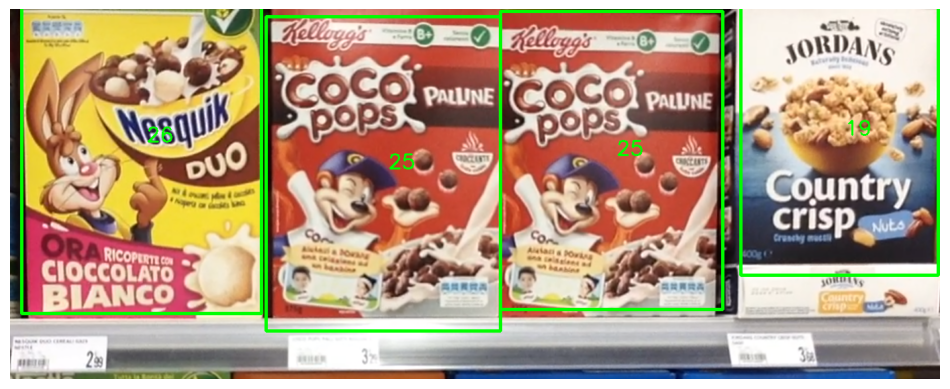

Product 0: 0 instance(s) found
Product 1: 0 instance(s) found
Product 11: 0 instance(s) found
Product 19: 1 instance(s) found
  Instance 1 {position: (1088, -5), width: 294px, height: 401px}
Product 24: 0 instance(s) found
Product 25: 2 instance(s) found
  Instance 1 {position: (730, 3), width: 331px, height: 444px}
  Instance 2 {position: (381, 11), width: 349px, height: 468px}
Product 26: 1 instance(s) found
  Instance 1 {position: (17, -43), width: 357px, height: 496px}

Processing scene: m4


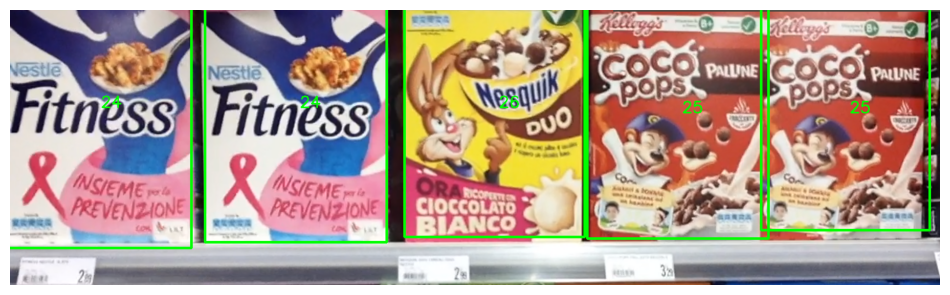

Product 0: 0 instance(s) found
Product 1: 0 instance(s) found
Product 11: 0 instance(s) found
Product 19: 0 instance(s) found
Product 24: 2 instance(s) found
  Instance 1 {position: (-16, -64), width: 362px, height: 519px}
  Instance 2 {position: (372, -54), width: 347px, height: 498px}
Product 25: 2 instance(s) found
  Instance 1 {position: (1102, -27), width: 346px, height: 464px}
  Instance 2 {position: (1434, -11), width: 322px, height: 432px}
Product 26: 1 instance(s) found
  Instance 1 {position: (753, -44), width: 344px, height: 478px}

Processing scene: m5


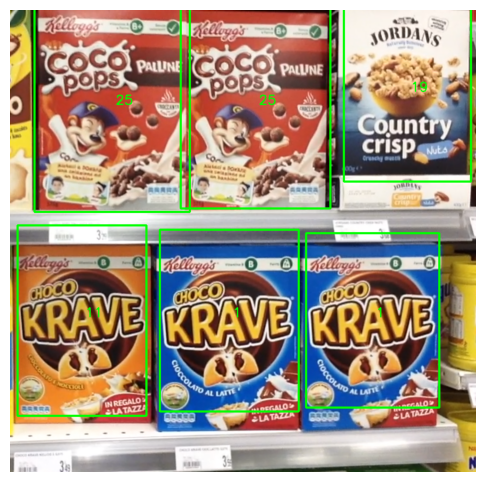

Product 0: 0 instance(s) found
Product 1: 2 instance(s) found
  Instance 1 {position: (345, 506), width: 320px, height: 419px}
  Instance 2 {position: (682, 514), width: 307px, height: 402px}
Product 11: 1 instance(s) found
  Instance 1 {position: (17, 496), width: 297px, height: 439px}
Product 19: 1 instance(s) found
  Instance 1 {position: (769, -4), width: 293px, height: 399px}
Product 24: 0 instance(s) found
Product 25: 2 instance(s) found
  Instance 1 {position: (56, -15), width: 358px, height: 480px}
  Instance 2 {position: (393, -6), width: 345px, height: 463px}
Product 26: 0 instance(s) found


In [96]:
model_features = {}
for pid in STEP_B_PRODUCTS:
    m_bgr = cv2.imread(str(MODELS_DIR / f"{pid}.jpg"), cv2.IMREAD_COLOR)
    m_gray = cv2.cvtColor(m_bgr, cv2.COLOR_BGR2GRAY)
    kp_m, des_m = get_features(m_gray)
    jvecs_m = compute_joining_vectors(kp_m, m_gray.shape)
    model_features[pid] = {"bgr": m_bgr, "gray": m_gray, "kp": kp_m, "des": des_m, "jvecs": jvecs_m}

# Iterative masking is utilized to allow multiple products to be detected in the same scene without
# one product's detections interfering with another's. 
for scene_name in STEP_B_SCENES:
    sid = scene_name.replace(".png", "") 
    scene_bgr = cv2.imread(str(SCENES_DIR / scene_name), cv2.IMREAD_COLOR)
    scene_gray = cv2.cvtColor(scene_bgr, cv2.COLOR_BGR2GRAY) 

    remaining_bgr  = scene_bgr.copy()
    remaining_gray = scene_gray.copy()
    remaining_pids = set(STEP_B_PRODUCTS)
    detections = []  # list of (pid, inst)

    while remaining_pids:
        kp_s, des_s = get_features(remaining_gray)

        best = None  # (pid, score, accepted_instances)
        for pid in remaining_pids:
            m = model_features[pid]
            good = match_descriptors(m["des"], des_s)
            if len(good) < MIN_GOOD_MATCHES:
                continue

            _, peaks, votes = ght_vote_and_peaks(good, m["kp"], kp_s, m["jvecs"], scene_gray.shape)
            instances = peaks_to_instances(peaks, votes, m["gray"].shape)

            accepted = []
            for inst in instances:
                warped = instance_to_quad(inst)
                if color_distance(m["bgr"], scene_bgr, warped) > COLOR_TOL:
                    continue
                accepted.append(inst)

            if not accepted:
                continue

            
            score = len(accepted) * len(good)
            if best is None or score > best[1]:
                best = (pid, score, accepted)

        if best is None:
            break

        pid, _, accepted = best
        for inst in accepted:
            detections.append((pid, inst))
            quad = instance_to_quad(inst)
            cv2.fillPoly(remaining_bgr,  [np.int32(quad)], (0, 0, 0))
            cv2.fillPoly(remaining_gray, [np.int32(quad)], 0)
        remaining_pids.discard(pid)

    # Draw all winning detections on the original scene
    scene_with_boxes = scene_bgr.copy()
    instances_by_pid = {pid: [] for pid in STEP_B_PRODUCTS}
    for pid, inst in detections:
        cx, cy = inst["center"]
        x0, y0 = cx - inst["width"] // 2, cy - inst["height"] // 2
        cv2.rectangle(scene_with_boxes, (x0, y0),
                      (x0 + inst["width"], y0 + inst["height"]), (0, 255, 0), 3)
        cv2.putText(scene_with_boxes, pid, (cx + 8, cy - 8),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
        instances_by_pid[pid].append({
            "position": (x0, y0),
            "width": inst["width"],
            "height": inst["height"],
        })

    print(f"\n\033[1mProcessing scene: {sid}\033[0m")
    plt.figure(figsize=(12, 6))
    plt.imshow(cv2.cvtColor(scene_with_boxes, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

    for pid in STEP_B_PRODUCTS:
        n = len(instances_by_pid[pid])
        print(f"Product {pid}: {n} instance(s) found")
        for i, inst in enumerate(instances_by_pid[pid], 1):
            print(f"  Instance {i} {{position: {inst['position']}, "
                  f"width: {inst['width']}px, height: {inst['height']}px}}")